# Learning an antiderivative operator

This tutorial demonstrates how to train a Fourier neural operator (FNO) 
to learn an antiderivative operator.

**Note:** To run this notebook, users should have ipykernel and matplotlib
installed. This can be done by running 
```bash
uv sync --extra notebooks
```
in the terminal.

## Problem statement

We'll train an FNO to learn the mapping $G : u \rightarrow v$, where
$$ v(x) = \int_0^x u(t)\, dt $$
for
$$ u(x) = \sin(\alpha x), \quad x \in [0, 2\pi], \quad \alpha \in [0.5, 1] $$
and where $u$, $v$ have periodic boundary conditions.

## Data generation

Create synthetic training data:

In [1]:
import jax
import jax.numpy as jnp

from norax.data import DataLoader

# Use CPU if running on macOS since 
# Apple Metal does not support complex arithmetic
jax.config.update('jax_platform_name', 'cpu')

key = jax.random.key(0)

# Configuration
resolution = 32
n_samples = 132
n_train = 108
n_test = 24
batch_size = 12

# Domain
L = 2 * jnp.pi
h = L / resolution
grid = jnp.linspace(0, L - h, resolution)
x = jnp.tile(grid, (n_samples, 1))

# Random coefficients
key, subkey = jax.random.split(key)
alpha = 0.5 * (1 + jax.random.uniform(subkey, (n_samples,)))

# Generate u and v = integral_0^x u(t) dt
u = jnp.sin(alpha[:, None] * x)
v = (1 - jnp.cos(alpha[:, None] * grid)) / alpha[:, None]

x = x[..., None]  # shape: (n_samples, resolution, 1)
u = u[..., None]  # shape: (n_samples, resolution, 1)
v = v[..., None]  # shape: (n_samples, resolution, 1)
inputs = jnp.concatenate([x, u], axis=-1)  # shape: (n_samples, resolution, 2)
outputs = v  # shape: (n_samples, resolution, 1)

# Split into train and test sets
train_data = {"input": inputs[:n_train, ...], "output": outputs[:n_train, ...]}
test_data = {"input": inputs[-n_test:, ...], "output": outputs[-n_test:, ...]}

key, subkey1, subkey2 = jax.random.split(key, 3)
train_loader = DataLoader(subkey1, train_data, batch_size, shuffle=True)
test_loader = DataLoader(subkey2, test_data, batch_size, shuffle=True);

W0000 00:00:1774543184.456314 4991569 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1774543184.569403 4991569 service.cc:145] XLA service 0x930325000 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774543184.569518 4991569 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1774543184.573421 4991569 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1774543184.573451 4991569 mps_client.cc:384] XLA backend will use up to 5726240768 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



In [2]:
# Verify that JAX is working correctly with complex numbers
jnp.ones(1) + 1j * jnp.ones(1)

Array([1.+1.j], dtype=complex64)

## Model specification

In [3]:
from norax.models import FNO

model = FNO(
    key, 
    channels_in=2, 
    channels_out=1, 
    n_modes=(12,), 
    width=64, 
    depth=4
)

Print the model structure:

In [4]:
print(model)

FNO(
  depth=4,
  lift=MLP(
    input_dim=2,
    output_dim=64,
    width=0,
    depth=1,
    layers=[Linear(weight=f32[64,2], bias=f32[64])],
    activation=<function gelu>
  ),
  fourier_layers=[
    Fourier(
      spectral=SpectralConv(
        channels_in=64,
        channels_out=64,
        n_modes=(12,),
        n_spatial_dims=1,
        weights=c64[64,64,12]
      ),
      linear=Linear(weight=f32[64,64], bias=f32[64]),
      activation=<function gelu>
    ),
    Fourier(
      spectral=SpectralConv(
        channels_in=64,
        channels_out=64,
        n_modes=(12,),
        n_spatial_dims=1,
        weights=c64[64,64,12]
      ),
      linear=Linear(weight=f32[64,64], bias=f32[64]),
      activation=<function gelu>
    ),
    Fourier(
      spectral=SpectralConv(
        channels_in=64,
        channels_out=64,
        n_modes=(12,),
        n_spatial_dims=1,
        weights=c64[64,64,12]
      ),
      linear=Linear(weight=f32[64,64], bias=f32[64]),
      activation=<funct

Verify that a forward pass works:

In [5]:
x = train_data["input"][:2, :, :]
y = jax.vmap(model)(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {y.shape}")

Input shape: (2, 32, 2)
Output shape: (2, 32, 1)


## Evaluation

In [6]:
from functools import partial

def relative_l2_error(prediction: jax.Array, target: jax.Array) -> jax.Array:
    return jnp.linalg.norm(prediction - target) / jnp.linalg.norm(target)

@partial(jax.vmap, in_axes=(None, 0, 0))  # Vectorise over inputs and outputs
def loss_fn(model: FNO, inputs: jax.Array, targets: jax.Array) -> jax.Array:
    predictions = model(inputs)
    return relative_l2_error(predictions, targets)

@jax.jit
def eval_step(model: FNO, x: jax.Array, y: jax.Array) -> jax.Array:
    return jnp.sum(loss_fn(model, x, y))

def evaluate(model: FNO, dataloader: DataLoader):
    """Evaluate the model on the test data."""
    running_avg = 0  # Running average loss
    seen = 0  # Number of seen samples

    for batch in dataloader:
        x = batch["input"]
        y = batch["output"]
        n = x.shape[0]  # Number of samples in this batch
        seen += n
        running_avg += (eval_step(model, x, y) - n * running_avg) / seen

    return running_avg

In [7]:
x = train_data["input"][:2, ...]
y = train_data["output"][:2, ...]

loss_value = loss_fn(model, x, y)
print(loss_value.shape)

evaluate(model, test_loader)

(2,)


Array(0.95204484, dtype=float32)

## Training

Create an optax optimiser with an exponentially decaying learning rate:

In [8]:
import optax

# Learning rate schedule
learning_rate = 1e-3
steps_per_epoch = len(train_loader)

schedule = optax.schedules.exponential_decay(
    learning_rate,
    transition_steps=steps_per_epoch * 100,  # Decay every 100 epochs
    decay_rate=0.5,
    staircase=True,
)

optimiser = optax.adam(schedule)

Define a single training step, i.e. a batch update:

In [9]:
import equinox as eqx
from functools import partial

@partial(jax.jit, donate_argnums=(0, 1))
def train_step(model: FNO, opt_state, x: jax.Array, y: jax.Array):
    loss, grads = jax.value_and_grad(
        lambda m: jnp.mean(loss_fn(m, x, y))
    )(model)
    updates, opt_state = optimiser.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

Run the training loop:

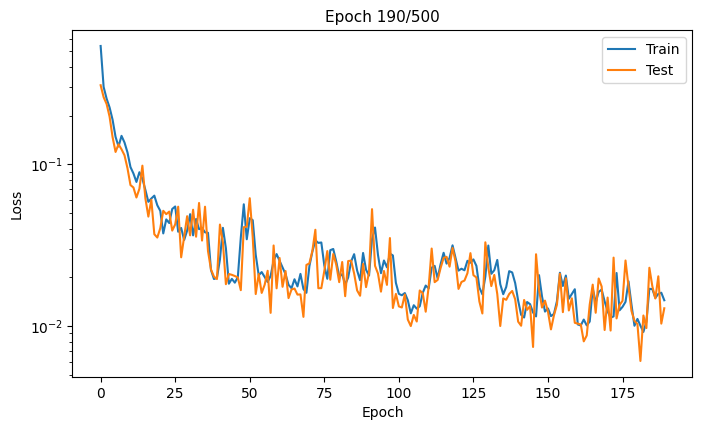

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output


def train(model: FNO, opt_state, dataloader: DataLoader):
    """Run one epoch of training.

    Returns:
        Updated model, optimizer state, and average per-sample loss for the epoch.
    """
    running_avg = 0.0
    seen = 0
    for batch in dataloader:
        x = batch["input"]
        y = batch["output"]
        n = x.shape[0]
        seen += n
        model, opt_state, batch_loss = train_step(model, opt_state, x, y)
        running_avg += n * (batch_loss - running_avg) / seen
    return model, opt_state, running_avg


n_epochs = 500
history = {"train_loss": [], "test_loss": []}
train_loader.reset()
test_loader.reset()
opt_state = optimiser.init(eqx.filter(model, eqx.is_array))

for epoch in range(1, n_epochs + 1):

    model, opt_state, train_loss = train(model, opt_state, train_loader)
    train_loader.reset()
    history["train_loss"].append(float(train_loss))

    test_loss = evaluate(model, test_loader)
    test_loader.reset()
    history["test_loss"].append(float(test_loss))

    if (epoch % 10 == 0) or (epoch == n_epochs):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel("Loss", fontsize=10)
        ax.set_yscale("log")
        ax.plot(history["train_loss"], label="Train")
        ax.plot(history["test_loss"], label="Test")
        ax.legend()
        ax.set_title(f"Epoch {epoch}/{n_epochs}", fontsize=11)
        plt.show()

## Visualisation

In [ ]:
key, subkey = jax.random.split(key)

n_examples = 3
n_test = test_data['input'].shape[0]

example_indices = jax.random.choice(subkey, jnp.arange(n_test), (3,))

selected_inputs = test_data['input'][example_indices]
selected_outputs = test_data['output'][example_indices]
predictions = jax.vmap(model)(selected_inputs)

fig, axes = plt.subplots(1, n_examples, figsize=(16, 9/2), layout='tight')

for i in range(len(axes)):
    ax = axes[i]
    idx = example_indices[i]

    x = selected_inputs[i, :, 0]
    u0 = selected_inputs[i, :, 1]
    v_true = selected_outputs[i, ...]
    v_pred = predictions[i, ...]

    # Plot
    ax.plot(x, u0, '-', label='Input $u$', linewidth=2, alpha=0.8)
    ax.plot(x, v_pred, '-', label='Predicted $v$', linewidth=2, alpha=0.8)
    ax.plot(x, v_true, ':', label='Ground truth $v$', linewidth=2, alpha=0.8)

    # Error
    l2_error = jnp.linalg.norm(v_pred - v_true) / jnp.linalg.norm(v_true)
    ax.set_title(f'Sample {idx}, L2 Error: {l2_error:.2e}', fontsize=11)
    ax.set_xlabel('$x$', fontsize=10)
    ax.legend(fontsize=10)

plt.show()